# 🦁 [3주차] 데이터 전처리 실습
**멋쟁이사자처럼 순천향대 14기 AI 파트**

> 이번 실습에서는 1주차에 사용했던 **타이타닉 데이터셋**을 활용하여,
> 데이터 전처리의 전 과정을 **단계별로 직접 수행**합니다.
>
> 목표: "Garbage In, Garbage Out" — 좋은 데이터가 좋은 모델을 만든다!

---
## STEP 0. 환경 세팅 & 데이터 로드

실습에 필요한 라이브러리를 불러오고, 타이타닉 데이터를 로드합니다.

In [1]:
# ============================================================
# 필요한 라이브러리 불러오기
# ============================================================

# pandas: 엑셀처럼 표(DataFrame) 형태로 데이터를 다루는 도구입니다.
# 줄여서 pd라고 별명을 붙여줍니다. (관례)
import pandas as pd

# numpy: 수학 연산(평균, 표준편차 등)을 빠르게 해주는 도구입니다.
# 줄여서 np라고 별명을 붙여줍니다. (관례)
import numpy as np

# matplotlib.pyplot: 그래프(차트)를 그려주는 시각화 도구입니다.
# 줄여서 plt라고 별명을 붙여줍니다. (관례)
import matplotlib.pyplot as plt

# seaborn: matplotlib 위에 만들어진 더 예쁜 시각화 도구입니다.
# 줄여서 sns라고 별명을 붙여줍니다. (관례)
import seaborn as sns

# warnings: 파이썬이 뱉는 경고 메시지를 숨겨줍니다.
# (실습에 불필요한 경고가 뜨는 걸 방지하기 위해 사용합니다)
import warnings
warnings.filterwarnings('ignore')

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [2]:
# ============================================================
# 타이타닉 데이터 불러오기
# ============================================================

# pd.read_csv(): CSV(엑셀과 비슷한 형식) 파일을 읽어서 DataFrame으로 만듭니다.
# 아래 URL은 GitHub에 공개된 타이타닉 데이터의 주소입니다.
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# df.shape: 데이터의 (행의 수, 열의 수)를 알려줍니다.
# 행(Row) = 승객 한 명 한 명의 정보
# 열(Column) = 나이, 성별, 운임 등 각각의 특성(Feature)
print(f"데이터 크기: {df.shape}")
print(f"→ 총 {df.shape[0]}명의 승객, {df.shape[1]}개의 특성(컬럼)이 있습니다.")
print()

# df.head(): 데이터의 맨 위 5줄만 미리보기합니다.
# 전체를 출력하면 너무 길어지니까, 맛보기로 5줄만 봅니다!
df.head()

데이터 크기: (891, 12)
→ 총 891명의 승객, 12개의 특성(컬럼)이 있습니다.



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## STEP 1. 데이터 탐색 (EDA: Exploratory Data Analysis)

모델에 데이터를 넣기 전, **데이터의 생김새를 먼저 파악**하는 것이 전처리의 첫걸음입니다.
- 어떤 컬럼이 있는지?
- 비어있는 값(결측치)은 얼마나 되는지?
- 숫자의 범위와 분포는 어떤지?

In [3]:
# ============================================================
# 데이터 기본 정보 확인하기
# ============================================================

# df.info(): 각 컬럼의 이름, 데이터 타입(숫자/문자), 비어있지 않은 값의 개수를 보여줍니다.
# Non-Null Count가 전체 행 수(891)보다 적으면 → 그 차이만큼 결측치(빈칸)가 있다는 뜻!
# 예: Age가 714 non-null이면 → 891 - 714 = 177개의 나이 정보가 비어있다는 의미입니다.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# ============================================================
# 수치형 컬럼 통계 요약
# ============================================================

# df.describe(): 숫자(int, float)로 이루어진 컬럼들의 통계를 한눈에 보여줍니다.
# count = 비어있지 않은 데이터 개수
# mean  = 평균값
# std   = 표준편차 (데이터가 평균으로부터 얼마나 퍼져있는지)
# min   = 최솟값
# 25%   = 하위 25% 지점의 값 (Q1, 1사분위수)
# 50%   = 중앙값 (Median, 데이터를 줄 세웠을 때 정가운데 값)
# 75%   = 상위 25% 지점의 값 (Q3, 3사분위수)
# max   = 최댓값
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# ============================================================
# 결측치(빈칸) 현황 파악하기
# ============================================================

# df.isnull(): 각 셀(칸)이 비어있으면 True, 아니면 False를 반환합니다.
# .sum(): True의 개수를 컬럼별로 세어줍니다. (True=1, False=0이므로)
missing = df.isnull().sum()

# 결측치 비율(%)도 함께 계산합니다.
# 전체 행 수(len(df) = 891) 대비 결측치가 몇 %인지 확인!
missing_pct = (missing / len(df)) * 100

# 결과를 보기 좋은 표로 만들어서 출력합니다.
missing_df = pd.DataFrame({
    '결측치 수': missing,
    '비율(%)': round(missing_pct, 2)  # 소수점 둘째자리까지 반올림
})

# 결측치가 0보다 큰 컬럼만 골라서, 비율이 높은 순서대로 정렬합니다.
# → 어떤 컬럼을 우선적으로 처리해야 하는지 한눈에 파악할 수 있습니다!
missing_df[missing_df['결측치 수'] > 0].sort_values('비율(%)', ascending=False)

,결측치 수,비율(%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


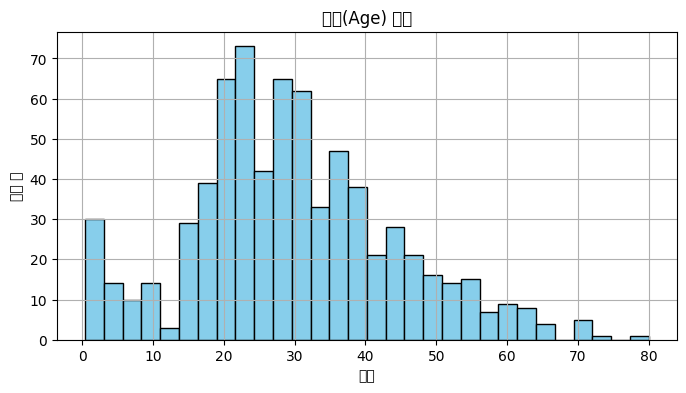

In [6]:
# ============================================================
# 나이(Age) 분포 시각화 (히스토그램)
# ============================================================

# 히스토그램: 특정 범위(구간)에 데이터가 몇 개 있는지를 막대로 보여주는 그래프입니다.
# → 데이터가 어디에 몰려있는지(분포)를 직관적으로 파악할 수 있습니다!

plt.figure(figsize=(8, 4))  # 그래프 크기를 가로 8인치, 세로 4인치로 설정합니다.

# bins=30: 나이 범위를 30개의 구간으로 나눠서 그립니다.
# edgecolor='black': 각 막대의 테두리를 검은색으로 그려서 구분이 쉽게 합니다.
# color='skyblue': 막대 색을 하늘색으로 설정합니다.
df['Age'].hist(bins=30, edgecolor='black', color='skyblue')

plt.title('나이(Age) 분포')   # 그래프 제목
plt.xlabel('나이')             # X축(가로축) 이름
plt.ylabel('승객 수')          # Y축(세로축) 이름
plt.show()                     # 그래프를 화면에 출력합니다!

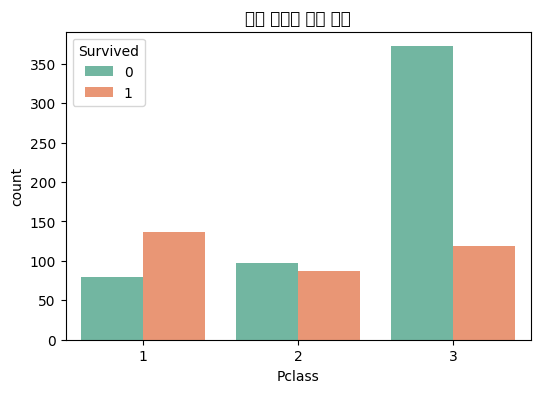

In [7]:
# ============================================================
# 객실 등급별 생존 여부 시각화 (카운트플롯)
# ============================================================

# countplot: 범주형 데이터의 빈도(개수)를 막대 그래프로 보여줍니다.
# x='Pclass': X축에 객실 등급(1등급, 2등급, 3등급)을 배치합니다.
# hue='Survived': 생존 여부(0=사망, 1=생존)에 따라 색을 나눠서 표시합니다.
# → 어떤 등급의 승객이 더 많이 생존했는지 한눈에 비교할 수 있습니다!

plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title('객실 등급별 생존 여부')
plt.show()

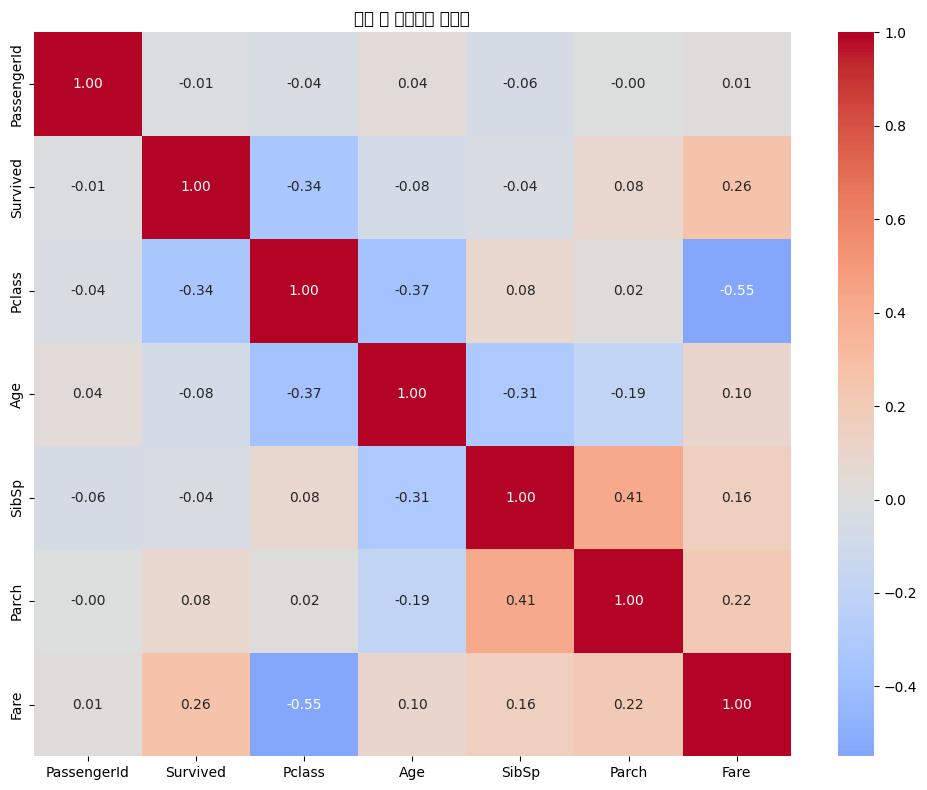

In [8]:
# ============================================================
# 상관관계 히트맵 (Correlation Heatmap)
# ============================================================

# 상관관계(Correlation): 두 변수가 얼마나 함께 움직이는지를 -1 ~ +1 사이의 숫자로 나타냅니다.
# +1에 가까우면: A가 커지면 B도 커진다 (강한 양의 상관관계)
# -1에 가까우면: A가 커지면 B는 작아진다 (강한 음의 상관관계)
# 0에 가까우면: A와 B는 별로 관련이 없다

plt.figure(figsize=(10, 8))  # 그래프를 크게 설정 (컬럼이 많으므로)

# select_dtypes(include=[np.number]): 숫자형 컬럼만 골라냅니다. (문자열은 상관관계 계산 불가)
# .corr(): 골라낸 숫자 컬럼들 간의 상관계수를 계산합니다.
numeric_df = df.select_dtypes(include=[np.number])

# heatmap: 상관관계 숫자를 색깔로 표현한 그래프입니다.
# annot=True: 각 칸에 상관계수 숫자를 직접 표시합니다.
# cmap='coolwarm': 파란색(음의 상관) ~ 빨간색(양의 상관) 색상표를 사용합니다.
# center=0: 상관계수 0을 색상의 중간(흰색)으로 설정합니다.
# fmt='.2f': 숫자를 소수점 둘째자리까지 표시합니다.
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')

plt.title('변수 간 상관관계 히트맵')
plt.tight_layout()  # 그래프가 잘리지 않도록 여백을 자동 조정합니다.
plt.show()

---
## STEP 2. 결측치 처리 (Missing Value)

결측치(NaN, None)란 **데이터가 비어 있는 칸**입니다.
대부분의 머신러닝 모델은 결측치가 있으면 에러가 나거나 성능이 크게 떨어집니다.

**처리 전략:**
- `Age` (19.9% 결측) → 중앙값으로 채우기 (이상치 영향 최소화)
- `Embarked` (0.2% 결측) → 최빈값으로 채우기 (범주형이므로)
- `Cabin` (77.1% 결측) → 너무 많이 비어있으니 컬럼 자체를 삭제

In [9]:
# ============================================================
# 결측치 처리하기
# ============================================================

# ── 처리 전 결측치 현황 확인 ──
print("=" * 40)
print("결측치 처리 전")
print("=" * 40)
print(df.isnull().sum())  # 각 컬럼별 결측치 개수 출력
print()

# ── 1. Age(나이): 중앙값(median)으로 채우기 ──
# 왜 평균이 아니라 중앙값?
# → 나이 데이터에 극단적인 값(예: 80세)이 있으면 평균이 왜곡될 수 있습니다.
# → 중앙값은 데이터를 크기순으로 줄 세웠을 때 정가운데 값이라 이상치에 덜 영향받습니다!
# .median(): 중앙값을 계산합니다.
# .fillna(): NaN(빈칸)을 괄호 안의 값으로 채워넣습니다.
df['Age'] = df['Age'].fillna(df['Age'].median())

# ── 2. Embarked(탑승 항구): 최빈값(mode)으로 채우기 ──
# Embarked는 C, Q, S 세 가지 범주(카테고리)입니다.
# 범주형 데이터는 평균이나 중앙값이 의미가 없으므로,
# 가장 많이 등장한 값(최빈값, mode)으로 채우는 것이 합리적입니다.
# .mode()[0]: 최빈값을 구합니다. ([0]은 최빈값이 여러 개일 때 첫 번째를 선택)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# ── 3. Cabin(객실 번호): 컬럼 자체를 삭제 ──
# Cabin은 결측치가 77%나 됩니다.
# 대부분이 비어있는 컬럼은 채워봤자 의미가 없으므로 과감히 제거합니다!
# .drop(columns=['컬럼명']): 해당 컬럼을 통째로 삭제합니다.
df = df.drop(columns=['Cabin'])

# ── 처리 후 결측치 현황 확인 ──
print("=" * 40)
print("결측치 처리 후")
print("=" * 40)
print(df.isnull().sum())  # 모든 컬럼이 0이면 성공!
print()
print("결측치 처리 완료! 모든 컬럼의 결측치가 0개입니다.")

결측치 처리 전
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

결측치 처리 후
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

결측치 처리 완료! 모든 컬럼의 결측치가 0개입니다.


---
## STEP 3. 이상치 확인 & 처리 (Outlier)

이상치란 **다른 데이터들과 동떨어진 극단적인 값**입니다.
예를 들어, 대부분의 운임이 0~50인데 혼자 500이라면? 모델이 그 값에 끌려가서 성능이 떨어질 수 있습니다.

**IQR(사분위 범위) 방법**으로 이상치를 탐지하고 제거합니다.

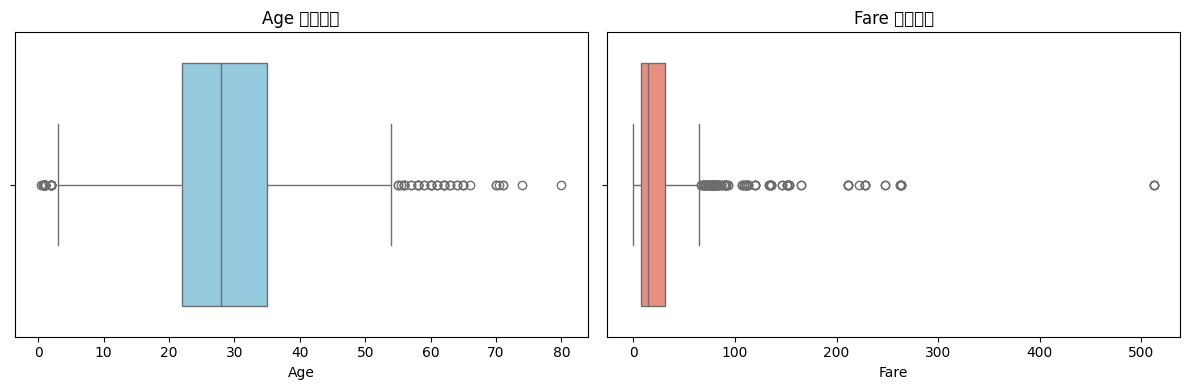

In [10]:
# ============================================================
# 박스플롯(Box Plot)으로 이상치 눈으로 확인하기
# ============================================================

# 박스플롯 읽는 법:
# ┌─────────────────────────────────────┐
# │  ●  ──|=====[  |  ]========|──  ●   │
# │ 이상치  Q1    Q2(중앙값)   Q3  이상치 │
# └─────────────────────────────────────┘
# 상자(Box) = Q1(25%) ~ Q3(75%) 범위 (데이터의 중간 50%가 이 안에 있음)
# 수염(Whisker) = 상자에서 1.5*IQR 범위까지
# 점(●) = 수염 바깥의 값 → 이것이 이상치(Outlier)!

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 그래프 2개를 가로로 나란히 배치

# 왼쪽: Age(나이)의 박스플롯
sns.boxplot(x=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Age 박스플롯')

# 오른쪽: Fare(운임)의 박스플롯
# → Fare 쪽에 점(●)이 많이 보인다면 이상치가 많다는 뜻!
sns.boxplot(x=df['Fare'], ax=axes[1], color='salmon')
axes[1].set_title('Fare 박스플롯')

plt.tight_layout()  # 그래프끼리 겹치지 않도록 자동 여백 조정
plt.show()

In [11]:
# ============================================================
# IQR(사분위 범위) 방법으로 Fare 이상치 제거하기
# ============================================================

# IQR 방법의 원리:
# 1. Q1(25%) 지점과 Q3(75%) 지점을 구합니다.
# 2. IQR = Q3 - Q1 (중간 50% 데이터의 범위)
# 3. 정상 범위 = [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
# 4. 이 범위를 벗어나면 이상치로 판단합니다!

# .quantile(0.25): 하위 25% 지점의 값 (= Q1, 1사분위수)
Q1 = df['Fare'].quantile(0.25)

# .quantile(0.75): 상위 25% 지점의 값 (= Q3, 3사분위수)
Q3 = df['Fare'].quantile(0.75)

# IQR: 사분위 범위 (Q3에서 Q1을 뺀 값)
# → 데이터의 중간 50%가 이 범위 안에 있습니다.
IQR = Q3 - Q1

# 정상 범위의 하한선과 상한선 계산
# 1.5는 통계학에서 관례적으로 사용하는 계수입니다.
lower = Q1 - 1.5 * IQR  # 이 값보다 작으면 이상치
upper = Q3 + 1.5 * IQR  # 이 값보다 크면 이상치

print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR (Q3 - Q1): {IQR:.2f}")
print(f"정상 범위: {lower:.2f} ~ {upper:.2f}")
print()

# 이상치 개수 확인
# (df['Fare'] < lower): Fare가 하한선보다 작은 데이터 → True
# (df['Fare'] > upper): Fare가 상한선보다 큰 데이터 → True
# | : OR 연산자 (둘 중 하나라도 True면 이상치)
outlier_count = ((df['Fare'] < lower) | (df['Fare'] > upper)).sum()
print(f"이상치 개수: {outlier_count}개")

# 이상치가 아닌 정상 데이터만 남기기
# & : AND 연산자 (두 조건 모두 True인 데이터만 살림)
before = len(df)
df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]
after = len(df)

print(f"이상치 제거 전: {before}행 → 제거 후: {after}행 (총 {before - after}행 제거)")

Q1 (25%): 7.91
Q3 (75%): 31.00
IQR (Q3 - Q1): 23.09
정상 범위: -26.72 ~ 65.63

이상치 개수: 116개
이상치 제거 전: 891행 → 제거 후: 775행 (총 116행 제거)


---
## STEP 4. 인코딩 (Encoding)

머신러닝 모델은 **숫자만 이해**합니다.
`"male"`, `"female"` 같은 문자(텍스트) 데이터는 반드시 숫자로 바꿔줘야 합니다!

- **레이블 인코딩:** 범주가 2개일 때 (예: male/female → 1/0)
- **원-핫 인코딩:** 범주가 3개 이상일 때 (예: C/Q/S → 별도 컬럼으로 분리)

In [12]:
# ============================================================
# 범주형 데이터를 숫자로 변환하기
# ============================================================

# sklearn.preprocessing: 데이터 전처리 도구 모음입니다.
# LabelEncoder: 문자 → 숫자로 바꿔주는 변환기입니다.
from sklearn.preprocessing import LabelEncoder

# ── 1. 레이블 인코딩: Sex(성별) ──
# Sex 컬럼은 'female'과 'male' 두 가지 범주만 있습니다.
# 범주가 2개뿐이면 레이블 인코딩(0, 1)으로 충분합니다!

le = LabelEncoder()  # 변환기 객체를 만듭니다.

# .fit_transform(): 두 가지 작업을 한번에 합니다.
#   fit: "female과 male이 있구나" 하고 학습합니다.
#   transform: female → 0, male → 1로 변환합니다. (알파벳 순서대로 번호 부여)
df['Sex'] = le.fit_transform(df['Sex'])

# 어떻게 변환되었는지 확인해봅시다!
# le.classes_: 인코더가 학습한 원래 범주들을 보여줍니다.
print("Sex 인코딩 결과:")
print(f"  {le.classes_} → {list(range(len(le.classes_)))}")
print(f"  즉, female=0, male=1 로 변환되었습니다!")
print()

# ── 2. 원-핫 인코딩: Embarked(탑승 항구) ──
# Embarked는 C(Cherbourg), Q(Queenstown), S(Southampton) 세 가지 범주입니다.
# 범주가 3개 이상이면 레이블 인코딩(0, 1, 2)을 쓰면 위험합니다!
# → 모델이 "S(2)가 C(0)보다 크다"고 착각할 수 있기 때문입니다.
# → 원-핫 인코딩으로 각 범주를 별도의 컬럼(0 또는 1)으로 분리합니다!

# pd.get_dummies(): 판다스에서 제공하는 가장 간편한 원-핫 인코딩 함수입니다.
# columns=['Embarked']: Embarked 컬럼을 원-핫 인코딩합니다.
# drop_first=True: 첫 번째 범주(C)의 컬럼을 삭제합니다.
#   → 왜? Q=0이고 S=0이면 자동으로 C라는 것을 알 수 있으니까!
#   → 불필요한 중복 정보를 제거하여 '다중공선성'을 방지합니다.
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# 결과 확인: Embarked 컬럼이 사라지고, Embarked_Q와 Embarked_S가 새로 생겼습니다!
print("원-핫 인코딩 후 컬럼 목록:")
print(list(df.columns))
print()
df.head()

Sex 인코딩 결과:
  ['female' 'male'] → [0, 1]
  즉, female=0, male=1 로 변환되었습니다!

원-핫 인코딩 후 컬럼 목록:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S']



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,False,True
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,False,True
5,6,0,3,"Moran, Mr. James",1,28.0,0,0,330877,8.4583,True,False


---
## STEP 5. 피처 스케일링 & 모델 학습

특성(Feature)마다 **값의 범위(스케일)가 제각각이면** 모델이 큰 숫자에 끌려갑니다.
- Age: 0~80 / Fare: 0~500 → 모델: "Fare가 더 중요하겠네!" (착각!)

스케일링으로 모든 특성의 범위를 맞춰주면 모델이 공평하게 학습합니다.

> **핵심 주의:** `fit_transform`은 **학습 데이터에만** 사용!
> 테스트 데이터에는 `transform`만! (Data Leakage 방지)

In [13]:
# ============================================================
# 전처리 마무리 + 모델 학습
# ============================================================

# 필요한 도구들을 불러옵니다.
# train_test_split: 데이터를 학습용/시험용으로 나눠주는 도구
from sklearn.model_selection import train_test_split

# StandardScaler: 데이터를 평균=0, 표준편차=1로 변환하는 스케일러
# → 공식: z = (x - 평균) / 표준편차
from sklearn.preprocessing import StandardScaler

# RandomForestClassifier: 나무 100그루가 투표하는 앙상블 분류 모델 (2주차에서 배웠죠!)
from sklearn.ensemble import RandomForestClassifier

# accuracy_score: 모델의 정확도(맞춘 비율)를 계산하는 도구
# classification_report: 정밀도, 재현율 등 상세한 성적표를 보여주는 도구
from sklearn.metrics import accuracy_score, classification_report

# AUTO-INJECTED: Korean font setup for matplotlib
import os as _os
import matplotlib.font_manager as _fm
import matplotlib.pyplot as _plt
if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
    for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                  '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
        if _os.path.exists(_font):
            _fm.fontManager.addfont(_font)
_plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
del _os, _fm, _plt
# END AUTO-INJECTED Korean font setup


# ── 1단계: 불필요한 컬럼 제거 ──
# Name(이름), Ticket(티켓번호), PassengerId(승객번호)는
# 생존 여부를 예측하는 데 도움이 되지 않는 정보입니다.
# → 모델에 불필요한 정보를 넣으면 오히려 혼란만 줍니다!
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])

# ── 2단계: 문제(X)와 정답(y) 분리 ──
# X: 모델이 보고 판단할 힌트들 (나이, 성별, 운임 등)
# y: 모델이 맞춰야 할 정답 (Survived: 0=사망, 1=생존)
X = df.drop(columns=['Survived'])  # Survived 컬럼만 빼고 나머지가 전부 X(문제)
y = df['Survived']                  # Survived 컬럼만 뽑아서 y(정답)

print(f"X(문제)의 크기: {X.shape} → {X.shape[0]}명의 승객, {X.shape[1]}개의 힌트")
print(f"y(정답)의 크기: {y.shape} → {y.shape[0]}개의 정답 (0 또는 1)")
print()

# ── 3단계: 학습용 / 시험용 데이터 분리 ──
# test_size=0.2: 전체 데이터의 20%를 시험용(Test)으로 빼둡니다.
#   → 80%로 공부하고, 20%로 시험 보는 것과 같은 원리!
# random_state=42: 난수 고정. 코드를 다시 실행해도 똑같이 쪼개집니다.
#   → 42는 관례적으로 자주 쓰는 숫자입니다. (은하수를 여행하는 히치하이커에서 유래)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"학습용 데이터: {X_train.shape[0]}명")
print(f"시험용 데이터: {X_test.shape[0]}명")
print()

# ── 4단계: 피처 스케일링 (StandardScaler) ──
# 가장 중요한 포인트!
# fit_transform()은 반드시 학습 데이터(X_train)에만 사용합니다!
# → fit: "학습 데이터의 평균은 ○○, 표준편차는 ○○이구나" 하고 기준을 학습
# → transform: 그 기준으로 데이터를 변환

# 테스트 데이터(X_test)에는 transform()만 사용합니다!
# → 학습 데이터에서 배운 기준(평균, 표준편차)을 그대로 적용
# → 왜? 시험 문제를 미리 보면 안 되니까! (Data Leakage = 데이터 누수 방지)

scaler = StandardScaler()  # 스케일러 객체 생성

# 학습 데이터: fit(기준 학습) + transform(변환) = fit_transform
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터: transform만! (학습 데이터의 기준으로 변환)
X_test_scaled = scaler.transform(X_test)

print("스케일링 완료!")
print(f"  스케일링 전 Age 범위: {X_train['Age'].min():.1f} ~ {X_train['Age'].max():.1f}")
print(f"  스케일링 후 Age 범위: {X_train_scaled[:, X_train.columns.get_loc('Age')].min():.2f} ~ {X_train_scaled[:, X_train.columns.get_loc('Age')].max():.2f}")
print()

# ── 5단계: 모델 학습 & 예측 ──
# RandomForestClassifier: 결정 트리 100그루가 각자 학습하고 다수결로 투표하는 모델
# n_estimators=100: 나무를 100그루 심겠다는 뜻
model = RandomForestClassifier(n_estimators=100, random_state=42)

# .fit(): 학습용 문제(X_train_scaled)와 정답(y_train)을 주고 패턴을 학습시킵니다.
model.fit(X_train_scaled, y_train)

# .predict(): 학습한 모델에게 처음 보는 시험 문제(X_test_scaled)를 풀게 합니다.
pred = model.predict(X_test_scaled)

# ── 6단계: 정확도 확인 ──
# accuracy_score: (맞춘 개수 / 전체 개수) × 100 = 정확도(%)
acc = accuracy_score(y_test, pred) * 100
print(f"전처리 완료 후 모델 정확도: {acc:.2f}%")
print()

# classification_report: 클래스별 정밀도(Precision), 재현율(Recall), F1-score를 보여줍니다.
# → 정확도만으로는 모델의 성능을 완전히 판단할 수 없기 때문에 함께 확인합니다!
print(classification_report(y_test, pred, target_names=['사망(0)', '생존(1)']))

X(문제)의 크기: (775, 8) → 775명의 승객, 8개의 힌트
y(정답)의 크기: (775,) → 775개의 정답 (0 또는 1)

학습용 데이터: 620명
시험용 데이터: 155명

스케일링 완료!
  스케일링 전 Age 범위: 0.4 ~ 80.0
  스케일링 후 Age 범위: -2.26 ~ 4.08

전처리 완료 후 모델 정확도: 76.13%

              precision    recall  f1-score   support

       사망(0)       0.78      0.85      0.81        95
       생존(1)       0.73      0.62      0.67        60

    accuracy                           0.76       155
   macro avg       0.75      0.73      0.74       155
weighted avg       0.76      0.76      0.76       155



---
## 전처리 유무 비교 실험

"전처리가 정말 중요한가?" 를 **숫자로 직접 체감**해봅시다!
- 전처리 없이: 숫자 컬럼만 뽑아서 바로 모델에 넣기
- 전처리 적용: 위에서 수행한 전체 파이프라인 적용

In [14]:
# ============================================================
# 전처리를 안 하면 정확도가 얼마나 차이날까?
# ============================================================

# ── 전처리 없는 버전 ──
# 원본 데이터를 다시 불러옵니다. (위에서 이미 전처리했으므로)
# 링크로 안되면 1주차 csv파일을 참고하세요!
df_raw = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# 전처리 없이 최소한의 처리만 합니다:
# 1. 숫자 컬럼만 골라냅니다. (문자 컬럼은 모델이 읽을 수 없으므로)
# 2. 결측치가 있는 행을 삭제합니다. (모델이 NaN을 처리할 수 없으므로)
# → 즉, 인코딩도 안 하고 스케일링도 안 한 날것(raw) 그대로!
df_raw = df_raw.select_dtypes(include=[np.number]).dropna()

# 문제(X)와 정답(y) 분리
X_raw = df_raw.drop(columns=['Survived'])
y_raw = df_raw['Survived']

# 학습/테스트 분리
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# 같은 RandomForest 모델로 학습 (공정한 비교를 위해 동일 조건)
model_raw = RandomForestClassifier(n_estimators=100, random_state=42)
model_raw.fit(X_train_r, y_train_r)
pred_raw = model_raw.predict(X_test_r)

# ── 결과 비교 ──
raw_acc = accuracy_score(y_test_r, pred_raw) * 100  # 전처리 없는 버전의 정확도
clean_acc = accuracy_score(y_test, pred) * 100       # 전처리한 버전의 정확도 (위에서 계산한 값)

print("=" * 50)
print("전처리 유무에 따른 정확도 비교")
print("=" * 50)
print(f"전처리 없이 숫자 컬럼만 사용: {raw_acc:.2f}%")
print(f"전처리 파이프라인 적용 후:    {clean_acc:.2f}%")
print(f"정확도 향상: +{clean_acc - raw_acc:.2f}%p")
print()
print("→ 같은 모델이라도 전처리를 제대로 하면 성능이 확 달라집니다!")
print("→ 이것이 'Garbage In, Garbage Out'의 의미입니다!")

전처리 유무에 따른 정확도 비교
전처리 없이 숫자 컬럼만 사용: 66.43%
전처리 파이프라인 적용 후:    76.13%
정확도 향상: +9.70%p

→ 같은 모델이라도 전처리를 제대로 하면 성능이 확 달라집니다!
→ 이것이 'Garbage In, Garbage Out'의 의미입니다!


---
## 3주차 과제

아래 **Heart Disease (심장병 예측)** 데이터셋을 사용하여 **직접 전처리 파이프라인을 구축**하고 모델 정확도를 출력하세요!

### 과제 수행 순서
1. 데이터 로드 & EDA (shape, info, describe, 결측치 확인)
2. 결측치 확인 및 처리
3. 이상치 확인 및 처리 (선택)
4. 인코딩 (범주형 → 숫자)
5. X, y 분리 (`target` 컬럼이 정답입니다!)
6. Train/Test Split
7. 스케일링
8. 모델 학습 & 정확도 출력

> **힌트:** 위에서 배운 코드를 참고하되, **데이터 특성에 맞게** 전처리 전략을 직접 결정해보세요!
> **힌트2:** `df.select_dtypes(include='object')` 로 문자열 컬럼만 골라낼 수 있습니다!

In [16]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [47]:
# ============================================================
# 과제 데이터 로드: Heart Disease (심장병 예측)
# ============================================================

# 이 데이터셋은 환자의 나이, 혈압, 콜레스테롤 등의 정보로
# 심장병 여부(target: 0=정상, 1=심장병)를 예측하는 데이터입니다.

df_mission = pd.read_csv('https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv')

print(f"데이터 크기: {df_mission.shape}")
print(f"→ 총 {df_mission.shape[0]}명의 환자, {df_mission.shape[1]}개의 특성")
print()
df_mission.head(10)

데이터 크기: (303, 14)
→ 총 303명의 환자, 14개의 특성



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  24

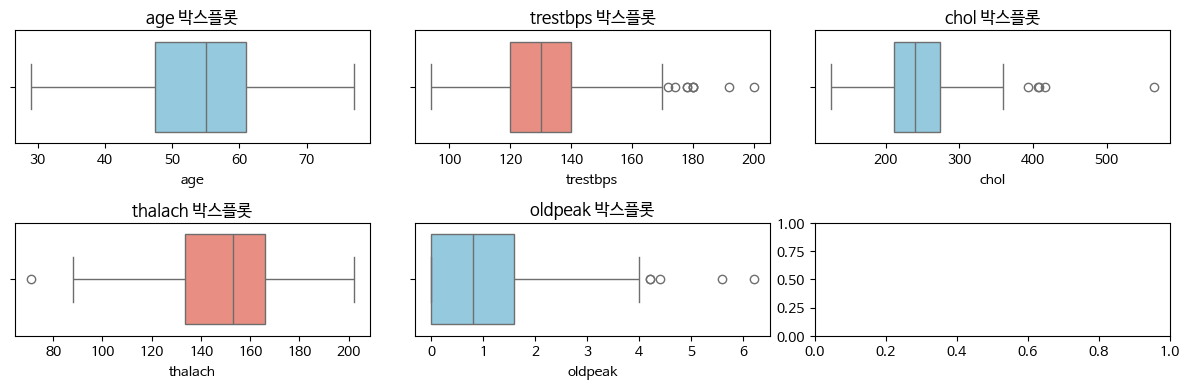

원-핫 인코딩 후 컬럼 목록:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']

학습용 데이터: 242
시험용 데이터: 61

전처리 완료 후 모델 정확도: 85.25%

              precision    recall  f1-score   support

       정상(0)       0.83      0.86      0.85        29
      심장병(1)       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [48]:
# ============================================================
# 여기에 전처리 파이프라인을 직접 작성하세요!
# ============================================================

# 1단계: EDA (데이터 탐색)
# → df_mission.info(), df_mission.describe(), df_mission.isnull().sum() 등
df_mission.info()
print(df_mission.describe())
print(df_mission.isnull().sum())

# 2단계: 결측치 처리
# → 결측치가 있다면 적절한 방법으로 처리하세요!
#결측치가 존재하지 않음


# 3단계: 이상치 처리 (선택사항)
# → 박스플롯으로 확인하고, 필요하면 IQR 방법으로 제거하세요!
fig, axes = plt.subplots(2, 3, figsize=(12, 4))

sns.boxplot(x=df_mission['age'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('age 박스플롯')

sns.boxplot(x=df_mission['trestbps'], ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('trestbps 박스플롯')

sns.boxplot(x=df_mission['chol'], ax=axes[0, 2], color='skyblue')
axes[0, 2].set_title('chol 박스플롯')

sns.boxplot(x=df_mission['thalach'], ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('thalach 박스플롯')

sns.boxplot(x=df_mission['oldpeak'], ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title('oldpeak 박스플롯')

plt.tight_layout()
plt.show()
# 큰 이상치가 없으므로 제거하지 않음

# 4단계: 인코딩
# → 문자열 컬럼을 찾아서 숫자로 바꿔주세요!
# → 힌트: df_mission.select_dtypes(include='object').columns
df_mission.select_dtypes(include='object').columns

df_mission = pd.get_dummies(df_mission, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)

print("원-핫 인코딩 후 컬럼 목록:")
print(list(df_mission.columns))
print()
df_mission.head()

# 5단계: X, y 분리
# → target 컬럼이 정답(y)입니다!
X = df_mission.drop(columns=['target'])
y = df_mission['target']

# 6단계: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"학습용 데이터: {X_train.shape[0]}")
print(f"시험용 데이터: {X_test.shape[0]}")
print()

# 7단계: 스케일링
# → fit_transform은 train에만! transform은 test에만!
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 8단계: 모델 학습 & 정확도 출력
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, pred) * 100
print(f"전처리 완료 후 모델 정확도: {acc:.2f}%")
print()
print(classification_report(y_test, pred, target_names=['정상(0)', '심장병(1)']))